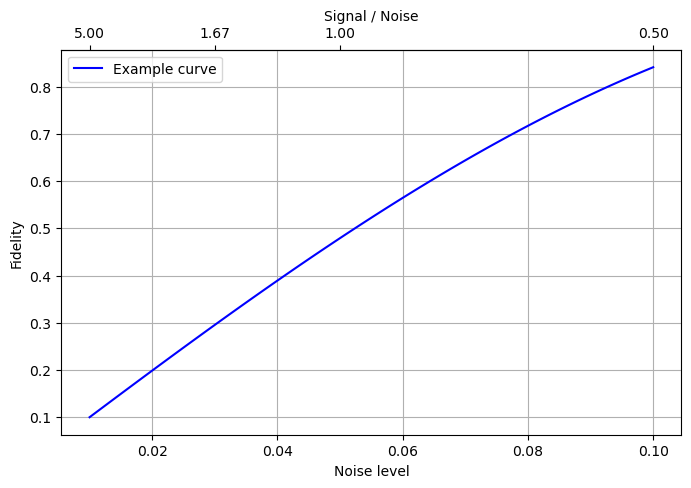

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data setup ---
x = np.linspace(0.01, 0.1, 100)
y = np.sin(10 * x)  # example data
snr_constant = 0.05  # constant for SNR calculation

# --- Create figure and primary axis ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, label='Example curve', color='blue')
ax.set_xlabel('Noise level')
ax.set_ylabel('Fidelity')

# --- Create top secondary x-axis ---
def snr_formatter(x_val):
    return f"{snr_constant / x_val:.2f}"

ax_top = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))  # identity mapping
ax_top.set_xlabel('Signal / Noise')
ax_top.set_xticks([0.01, 0.03, 0.05, 0.1])
ax_top.set_xticklabels([snr_formatter(xi) for xi in [0.01, 0.03, 0.05, 0.1]])

ax.grid(True)
ax.legend()
plt.show()


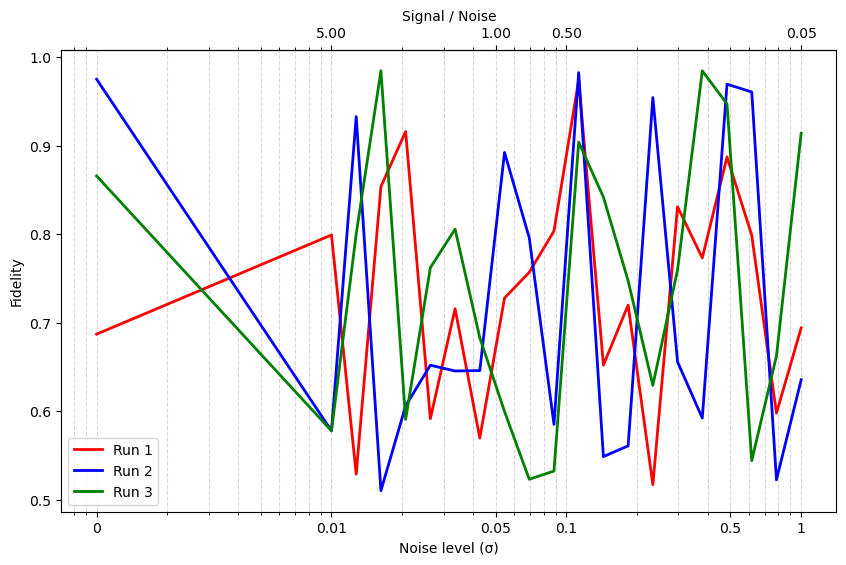

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data setup ---
# Original noise levels (with 0 prepended manually)
Log_Noises = np.logspace(np.log10(0.01), np.log10(1), 20)
Log_Noises = np.insert(Log_Noises, 0, 0.0)

# Replace 0 with a small positive number for plotting
x_plot = Log_Noises.copy()
x_plot[0] = 0.001  # small positive value instead of zero

# Example y-values for multiple runs
np.random.seed(42)
Fidelities = np.random.rand(len(x_plot), 3) * 0.5 + 0.5  # 3 curves, values 0.5-1

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Logarithmic x-axis
ax.set_xscale('log')
ax.plot(x_plot, Fidelities[:, 0], label='Run 1', color='red', linewidth=2)
ax.plot(x_plot, Fidelities[:, 1], label='Run 2', color='blue', linewidth=2)
ax.plot(x_plot, Fidelities[:, 2], label='Run 3', color='green', linewidth=2)

# Set x-axis ticks (replace first tick label with '0')
ticks = [0.001, 0.01, 0.05, 0.1, 0.5, 1]
tick_labels = ['0', '0.01', '0.05', '0.1', '0.5', '1']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Noise level (σ)")

ax.set_ylabel("Fidelity")
ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)

# --- Top secondary axis for SNR ---
snr_constant = 0.05  # example constant
def snr_label(x):
    return f"{snr_constant / x:.2f}"

# Secondary axis (identity mapping, just labels manually)
ax_top = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
snr_ticks = [0.01, 0.05, 0.1, 1.0]
ax_top.set_xticks(snr_ticks)
ax_top.set_xticklabels([snr_label(xi) for xi in snr_ticks])
ax_top.set_xlabel("Signal / Noise")

ax.legend()
plt.show()


/var/folders/04/zd672j0s59b0h_fl019y_21w0000gn/T/ipykernel_18286/4144916257.py:27: RuntimeWarning: divide by zero encountered in divide
  SignalTNoise = RegularSignal / np.sqrt(Log_Noises**2 + 4*Beta**2*InvSqr**2*Log_Noises**2/2)


[       inf 2.3570226  1.84969699 1.45156815 1.13913258 0.89394565
 0.70153276 0.55053483 0.4320377  0.33904589 0.26606964 0.2088008
 0.16385851 0.1285896  0.10091197 0.07919168 0.06214646 0.04877005
 0.03827278 0.03003495 0.02357023]


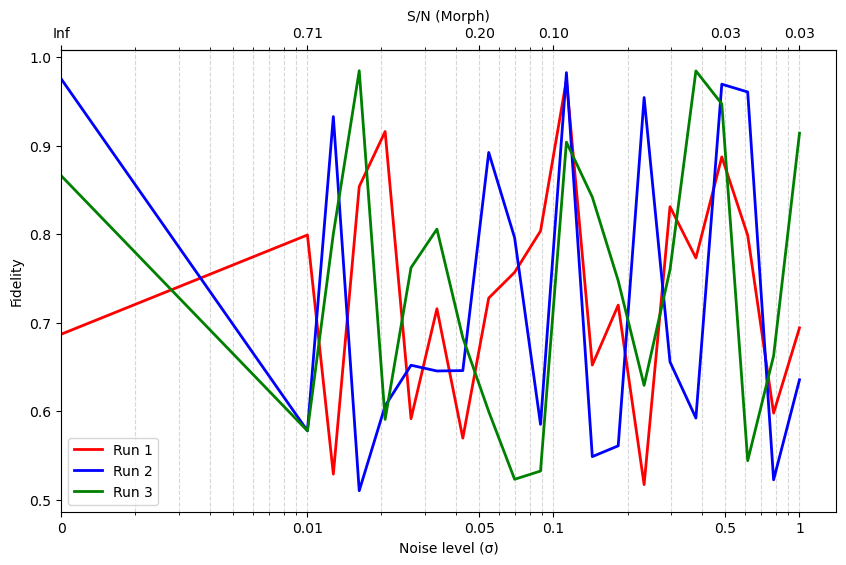

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
Beta = 10.0       # You can adjust this
InvSqr = 1/40     # adjustable if needed

# --- Noise arrays (with zero prepended manually) ---
Log_Noises = np.logspace(np.log10(0.01), np.log10(1), 20)
Log_Noises = np.insert(Log_Noises, 0, 0.0)

Log_Noises_Morph = np.logspace(np.log10(0.01), np.log10(0.25), 6)
Log_Noises_Morph = np.insert(Log_Noises_Morph, 0, 0.0)

# --- Replace 0 for plotting ---
x_plot = Log_Noises.copy()
x_plot[0] = 0.001  # small value for log scale

# Example y-values
np.random.seed(42)
Fidelities = np.random.rand(len(x_plot), 3) * 0.5 + 0.5  # 3 example curves

# --- Compute S/N values ---
RegularSignal = 1/40
MorphSignal = 1/20

SignalTNoise = RegularSignal / np.sqrt(Log_Noises**2 + 4*Beta**2*InvSqr**2*Log_Noises**2/2)
print(SignalTNoise)
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xscale('log')

# Plot example curves
colors = ['red', 'blue', 'green']
for i in range(Fidelities.shape[1]):
    ax.plot(x_plot, Fidelities[:, i], label=f'Run {i+1}', color=colors[i], linewidth=2)

# --- Lower x-axis ticks ---
ticks = [0.001, 0.01, 0.05, 0.1, 0.5, 1]
tick_labels = ['0', '0.01', '0.05', '0.1', '0.5', '1']  # fake 0
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Noise level (σ)")
ax.set_ylabel("Fidelity")

# Hide ticks left of fake zero
ax.set_xlim(left=0.001)

# --- Top axis for S/N ---
ax_top = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
snr_ticks = [0.001, 0.01, 0.05, 0.1, 0.5, 1]  # same positions
snr_labels = []
for xi in snr_ticks:
    if xi <= 0.001:
        snr_labels.append('Inf')  # show Inf for zero
    else:
        snr_labels.append(f"{SignalTNoiseMorph[np.argmin(np.abs(Log_Noises_Morph - xi))]:.2f}")

ax_top.set_xticks(snr_ticks)
ax_top.set_xticklabels(snr_labels)
ax_top.set_xlabel("S/N (Morph)")

# Hide ticks left of fake zero
ax_top.set_xlim(left=0.001)

ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)
ax.legend()
plt.show()


In [72]:
import h5py
import numpy as np

filename = "StripeResultsCompare.jld2"

with h5py.File(filename, "r") as f:
    Fidelities_NoInv = np.array(f["Fidelities_NoInv"])
    Analytical_Fidelity_NoInv = np.array(f["Analytical_Fidelity_NoInv"])
    Fidelities_All_FF = np.array(f["Fidelities_All_FF"])
    Log_Noises = np.array(f["Log_Noises_Out"])
    SignalTNoise = np.array(f["SignalTNoise"])
    Log_Noises_Morph = np.array(f["Log_Noises_Morph"])
    SignalTNoiseMorph = np.array(f["SignalTNoiseMorph"])

print("Loaded arrays:")
print("Fidelities_NoInv shape:", Fidelities_NoInv.shape)

with h5py.File("StripeResultsCompare_AltFF.jld2","r") as f:
    Fidelities_All_FF_Alt = np.array(f["Fidelities_All_FF"])
     

Loaded arrays:
Fidelities_NoInv shape: (7, 21)


In [61]:
Fidelities_All_FF = Fidelities_All_FF_Alt

In [40]:
SignalTNoise

array([       inf, 2.35702259, 1.84969698, 1.45156814, 1.13913257,
       0.89394565, 0.70153276, 0.55053483, 0.43203769, 0.33904589,
       0.26606964, 0.2088008 , 0.16385851, 0.1285896 , 0.10091197,
       0.07919168, 0.06214646, 0.04877005, 0.03827278, 0.03003495,
       0.02357023])

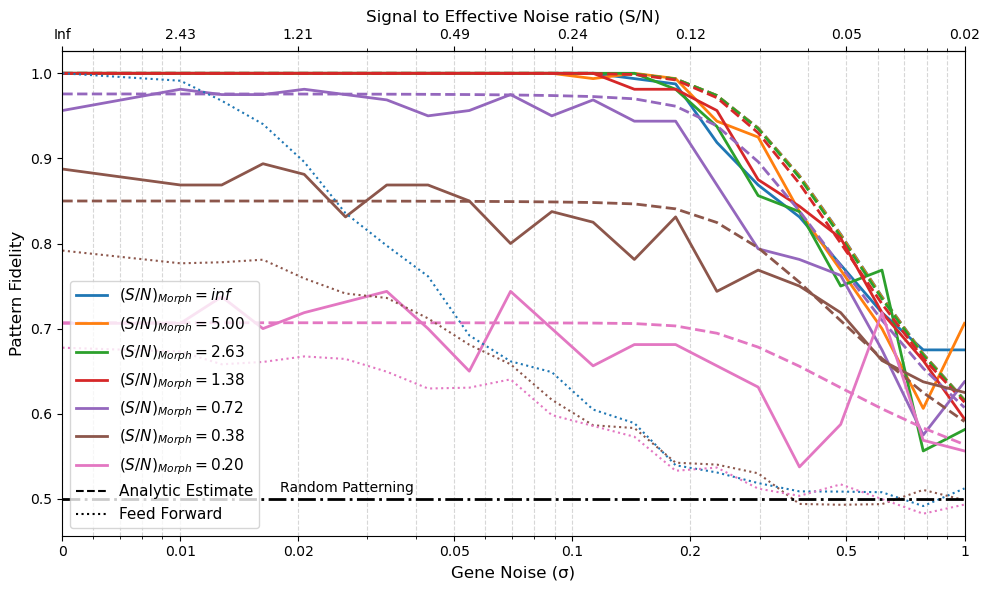

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# --- Replace 0 for plotting ---
x_plot = Log_Noises.copy()
x_plot[0] = 0.005  # fake zero for log-scale

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xscale('log')

n_morph = SignalTNoiseMorph.shape[0]

# Distinct qualitative colors
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(n_morph)]

for i in range(n_morph):

    morph_val = SignalTNoiseMorph[i]
    label = rf"$(S/N)_{{Morph}} = {morph_val:.2f}$"

    # Simulation (solid)
    ax.plot(
        x_plot,
        Fidelities_NoInv[i, :],
        color=colors[i],
        linewidth=2,
        linestyle='-',
        label=label
    )

    # Analytical (dashed, same color)
    ax.plot(
        x_plot,
        Analytical_Fidelity_NoInv[i, :],
        color=colors[i],
        linewidth=2,
        linestyle='--'
    )
    
Colours = [colors[0],colors[5],colors[6]]
for i in range(3):  
        ax.plot(
        x_plot,
        Fidelities_All_FF[:,i],
        color=Colours[i],
        linewidth=1.5,
        linestyle=':',
    )  
ax.plot(0.1,0.7,alpha=1,linestyle='--',label="Analytic Estimate",color='black')
        
ax.plot(0.1,0.7,alpha=1,linestyle=':',label="Feed Forward",color='black')

# --- Horizontal random line ---
ax.axhline(0.5, color='black', linestyle='dashdot', linewidth=2)
ax.text(
    0.018, 0.505,
    "Random Patterning",
    color='black',
    verticalalignment='bottom'
)

# --- Lower x-axis ticks ---
ticks = [0.005, 0.01,0.02, 0.05, 0.1, 0.2, 0.5, 1]
tick_labels = ['0', '0.01','0.02', '0.05','0.1','0.2', '0.5', '1']

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Gene Noise (σ)",fontsize=12)
ax.set_ylabel("Pattern Fidelity",fontsize=12)
ax.set_xlim(left=0.005,right=1)

ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)


# --- Compute S/N (example formula, adjust if needed) ---
#Beta = 10.0
#InvSqr = 1/40
#RegularSignal = 1/40



# --- Top axis for S/N ---
ax_top = ax.secondary_xaxis('top')

snr_ticks = ticks  # reuse same x positions
snr_labels = []

Counter = 0
for xi in snr_ticks:
    if xi <= 0.007:  # your fake-zero threshold
        snr_labels.append("Inf")
    else:
        Counter +=1
        idx = np.argmin(np.abs(x_plot - xi))
        snr_labels.append(f"{SignalTNoise[Counter]:.2f}")

ax_top.set_xticks(snr_ticks)
ax_top.set_xticklabels(snr_labels)
ax_top.set_xlabel("Signal to Effective Noise ratio (S/N)",fontsize=12)

ax_top.set_xlim(ax.get_xlim())




ax.legend(fontsize=11)
plt.tight_layout()
#plt.title("Fidelity Estimates",fontsize=16)
plt.savefig("Fidelity_Estimates_FFW.svg")
plt.savefig("Fidelity_Estimates_FFW.pdf")
plt.show()


In [74]:
RegularSignal = 1/40
Morphsignal = 1/20

#RegularNoise = sqrt(i^2 + 4*Beta^2*InvSqr^2*i^2/2) = sqrt(2)*Beta*i*InvSqr 
#MorphNoise = Effective_Noise_Morph = sqrt(...i^2 + Beta^2*j^2/2) = Beta*j/sqrt(2)
Beta = 10
InvSqr = 1/40
Log_Noises_Temp = np.array([0.005,0.01,0.02,0.05,0.1,0.2,0.5,1])
SignalTNoise = RegularSignal/np.sqrt(Log_Noises_Temp**2 + 2*Beta**2*InvSqr**2*Log_Noises_Temp**2/2)

In [67]:
SignalTNoise[0]

4.850712500726659

In [68]:
snr_ticks

[0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

In [69]:
Counter = 0
for xi in snr_ticks:
    if xi <= 0.007:  # your fake-zero threshold
        snr_labels.append("Inf")
    else:
        Counter +=1
        idx = np.argmin(np.abs(x_plot - xi))
        snr_labels.append(f"{SignalTNoise[Counter]:.2f}")

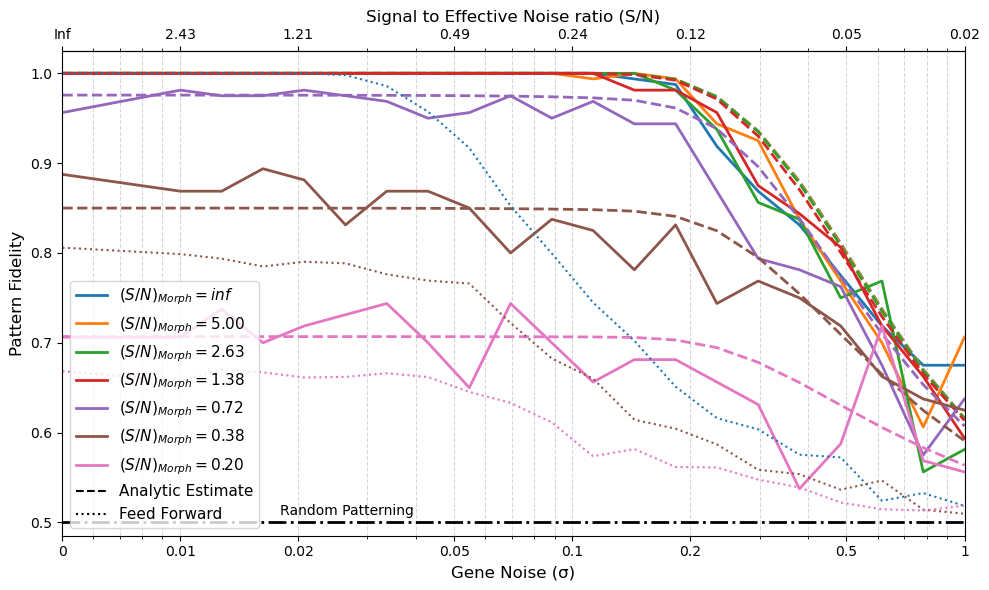

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- Replace 0 for plotting ---
x_plot = Log_Noises.copy()
x_plot[0] = 0.005  # fake zero for log-scale

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xscale('log')

n_morph = SignalTNoiseMorph.shape[0]

# Distinct qualitative colors
cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(n_morph)]

for i in range(n_morph):

    morph_val = SignalTNoiseMorph[i]
    label = rf"$(S/N)_{{Morph}} = {morph_val:.2f}$"

    # Simulation (solid)
    ax.plot(
        x_plot,
        Fidelities_NoInv[i, :],
        color=colors[i],
        linewidth=2,
        linestyle='-',
        label=label
    )

    # Analytical (dashed, same color)
    ax.plot(
        x_plot,
        Analytical_Fidelity_NoInv[i, :],
        color=colors[i],
        linewidth=2,
        linestyle='--'
    )
    
Colours = [colors[0],colors[5],colors[6]]
for i in range(3):  
        ax.plot(
        x_plot,
        Fidelities_All_FF[:,i],
        color=Colours[i],
        linewidth=1.5,
        linestyle=':',
    )  
ax.plot(0.1,0.7,alpha=1,linestyle='--',label="Analytic Estimate",color='black')
        
ax.plot(0.1,0.7,alpha=1,linestyle=':',label="Feed Forward",color='black')

# --- Horizontal random line ---
ax.axhline(0.5, color='black', linestyle='dashdot', linewidth=2)
ax.text(
    0.018, 0.505,
    "Random Patterning",
    color='black',
    verticalalignment='bottom'
)

# --- Lower x-axis ticks ---
ticks = [0.005, 0.01,0.02, 0.05, 0.1, 0.2, 0.5, 1]
tick_labels = ['0', '0.01','0.02', '0.05','0.1','0.2', '0.5', '1']

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Gene Noise (σ)",fontsize=12)
ax.set_ylabel("Pattern Fidelity",fontsize=12)
ax.set_xlim(left=0.005,right=1)

ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)


# --- Compute S/N (example formula, adjust if needed) ---
#Beta = 10.0
#InvSqr = 1/40
#RegularSignal = 1/40



# --- Top axis for S/N ---
ax_top = ax.secondary_xaxis('top')

snr_ticks = ticks  # reuse same x positions
snr_labels = []

Counter = 0
for xi in snr_ticks:
    if xi <= 0.007:  # your fake-zero threshold
        snr_labels.append("Inf")
    else:
        Counter +=1
        idx = np.argmin(np.abs(x_plot - xi))
        snr_labels.append(f"{SignalTNoise[Counter]:.2f}")

ax_top.set_xticks(snr_ticks)
ax_top.set_xticklabels(snr_labels)
ax_top.set_xlabel("Signal to Effective Noise ratio (S/N)",fontsize=12)

ax_top.set_xlim(ax.get_xlim())




ax.legend(fontsize=11)
plt.tight_layout()
#plt.title("Fidelity Estimates",fontsize=16)
plt.savefig("Fidelity_Estimates_FFW_Alt.svg")
plt.savefig("Fidelity_Estimates_FFW_Alt.pdf")
plt.show()
